In [ ]:
import pandas as pd
from tqdm import tqdm
from sentence_transformers import SentenceTransformer, util


c:\Users\Mateus Monteleone\Projects\ic\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
data_geral = pd.read_csv(
    "C:\\Users\\Mateus Monteleone\\Projects\\ic\\data\\df_padrao_geral.csv",
    encoding="utf-8-sig"  # ensures Excel-friendly UTF-8 
)

In [15]:
data_economica = pd.read_csv(
    "C:\\Users\\Mateus Monteleone\\Projects\\ic\\data\\df_padrao_economico.csv",
    encoding="utf-8-sig"  # ensures Excel-friendly UTF-8
)


In [43]:
data_econ_labelled = pd.read_csv("C:\\Users\\Mateus Monteleone\\Projects\\ic\\data\\df_economic_labelled.csv")

In [46]:
data_econ_labelled.head()

,processed_text,sentiment_label
0,maior furada essas pesquisas a globo anuncio...,2.0
1,1 dia pro 13\npor mais educação saúde empr...,1.0
2,bolsonaro tenha de todas as formas atingir o e...,2.0
3,1 dia pro 13\npor mais educação saúde empr...,1.0
4,neymar anistia federal de impostos ren...,2.0


In [44]:
data_geral_labelled = pd.read_csv("C:\\Users\\Mateus Monteleone\\Projects\\ic\\data\\df_labelled_geral.csv")

In [49]:
data_geral_labelled.head()

,processed_text,sentiment_label
0,Simone Tebet ultrapassa Ciro Gomes no Data Fol...,0.0
1,@CacauCFerreira @ciro_nogueira Kkkkkkkkk. Peti...,2.0
2,Ti me iludindo aqui achando q amanhã vou sair ...,2.0
3,@sacha_faria Não importa a pesquisa votem Ciro...,2.0
4,@Ragucha21 @ThiagoResiste LULA PRESIDENTE AMANHÃ,0.0


In [50]:
data_geral_labelled['is_economic'] = 0

In [52]:
data_econ_labelled['is_economic'] = 1

In [77]:
len(data_econ_labelled)

1722

In [78]:
data_econ_labelled.dropna(subset='sentiment_label', inplace=True)

In [72]:
len(data_geral_labelled)

54060

In [74]:
data_geral_labelled['sentiment_label'].isna().sum()

53933

In [76]:
data_geral_labelled.dropna(subset='sentiment_label', inplace=True)

In [53]:
data_econ_labelled.head()

,processed_text,sentiment_label,is_economic
0,maior furada essas pesquisas a globo anuncio...,2.0,1
1,1 dia pro 13\npor mais educação saúde empr...,1.0,1
2,bolsonaro tenha de todas as formas atingir o e...,2.0,1
3,1 dia pro 13\npor mais educação saúde empr...,1.0,1
4,neymar anistia federal de impostos ren...,2.0,1


In [23]:
data_geral.drop('target', axis='columns')

,processed_text,sentiment_label
0,Simone Tebet ultrapassa Ciro Gomes no Data Fol...,NaN
1,@CacauCFerreira @ciro_nogueira Kkkkkkkkk. Peti...,NaN
2,Ti me iludindo aqui achando q amanhã vou sair ...,NaN
3,@sacha_faria Não importa a pesquisa votem Ciro...,NaN
4,@Ragucha21 @ThiagoResiste LULA PRESIDENTE AMANHÃ,NaN
...,...,...
54055,LULA PRESIDENTE AMANHÃ https://t.co/aFeYyWrXAX,NaN
54056,A minha tia chorou de emoção falando que só Je...,NaN
54057,"Votar em Bolsonaro e Lula é meio que por medo,...",NaN
54058,@TomCavalcante1 Na verdade @TomCavalcante1 o ...,NaN


In [118]:
df_humano = pd.concat([data_econ_labelled, data_geral_labelled], ignore_index=True, verify_integrity=True)

In [119]:
df_humano.head()

,processed_text,sentiment_label,is_economic
0,maior furada essas pesquisas a globo anuncio...,2.0,1
1,1 dia pro 13\npor mais educação saúde empr...,1.0,1
2,bolsonaro tenha de todas as formas atingir o e...,2.0,1
3,1 dia pro 13\npor mais educação saúde empr...,1.0,1
4,neymar anistia federal de impostos ren...,2.0,1


In [121]:
df_humano.dropna(subset=['sentiment_label', 'is_economic'])

,processed_text,sentiment_label,is_economic
0,maior furada essas pesquisas a globo anuncio...,2.0,1
1,1 dia pro 13\npor mais educação saúde empr...,1.0,1
2,bolsonaro tenha de todas as formas atingir o e...,2.0,1
3,1 dia pro 13\npor mais educação saúde empr...,1.0,1
4,neymar anistia federal de impostos ren...,2.0,1
...,...,...,...
280,Representante da ESPANHA está com BOLSONARO! \...,0.0,0
281,@tesoureiros Lula presidente amanhã \n\n#Lula13,0.0,0
282,Bolsonaro expôs a situação do Exército hoje: s...,2.0,0
283,@ValdiviaLiette @RamosEneildes @LulaPTnosTrend...,0.0,0


In [122]:
len(df_humano)

285

In [24]:
df = pd.concat([data_geral,data_economica], ignore_index=True)

In [32]:
len(df)

55782

In [34]:
df['is_economic'] = pd.NA

In [ ]:
model = SentenceTransformer('neuralmind/bert-base-portuguese-cased')

# Define positive and negative reference sentences
ref_pos = model.encode("bom ótimo excelente feliz positivo maravilhoso incrível sucesso alegria incrível empolgação", convert_to_tensor=True)
ref_neg = model.encode("ruim péssimo horrível triste negativo fracasso crise problema decepção infeliz", convert_to_tensor=True)

No sentence-transformers model found with name neuralmind/bert-base-portuguese-cased. Creating a new one with mean pooling.


In [130]:
# Function to compute unsupervised sentiment
def get_unsupervised_sentiment(text):
    if not isinstance(text, str) or text.strip() == "":
        return 0  # neutral for empty/missing text
    emb = model.encode(text, convert_to_tensor=True)
    pos_sim = util.cos_sim(emb, ref_pos).item()
    neg_sim = util.cos_sim(emb, ref_neg).item()
    if pos_sim - neg_sim > 0.01:
        return 1
    elif neg_sim - pos_sim > 0.01:
        return -1
    else:
        return 0

In [125]:
df_humano['sentiment_label'] = df_humano['sentiment_label'].replace({2: -1})

In [135]:
df_humano.drop_duplicates(subset='processed_text', inplace=True)

In [136]:
df_humano['unsupervised_sentiment'] = df_humano['processed_text'].progress_apply(get_unsupervised_sentiment)


Calculando sentimento não supervisionado (BERTimbau): 100%|██████████| 234/234 [00:16<00:00, 14.25it/s]


In [137]:
df_humano['unsupervised_sentiment'].value_counts()

unsupervised_sentiment
-1    175
 0     35
 1     24
Name: count, dtype: int64

Acurácia: 0.5
y_true unique: [-1.  1.  0.]
y_pred unique: [-1  0  1]
y_true NaNs: 0
y_pred NaNs: 0
Tamanho y_true: 234
Tamanho y_pred: 234

Relatório de classificação:
               precision    recall  f1-score   support

        -1.0       0.52      0.83      0.64       110
         0.0       0.63      0.24      0.35        92
         1.0       0.17      0.12      0.14        32

    accuracy                           0.50       234
   macro avg       0.44      0.40      0.38       234
weighted avg       0.51      0.50      0.46       234



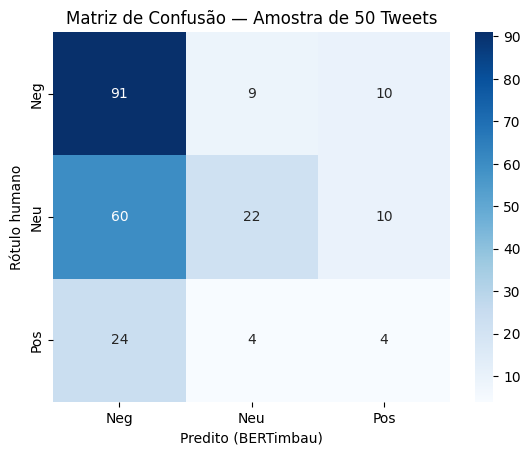

In [138]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Modelo BERTimbau

df_eval = df_humano.dropna(subset=['sentiment_label', 'unsupervised_sentiment'])

# Agora pode calcular as métricas sem erro
y_true = df_eval['sentiment_label']
y_pred = df_eval['unsupervised_sentiment']

print("Acurácia:", accuracy_score(y_true, y_pred))
print("y_true unique:", y_true.unique())
print("y_pred unique:", y_pred.unique())
print("y_true NaNs:", y_true.isna().sum())
print("y_pred NaNs:", y_pred.isna().sum())
print("Tamanho y_true:", len(y_true))
print("Tamanho y_pred:", len(y_pred))
print("\nRelatório de classificação:\n", classification_report(y_true, y_pred))

# Matriz de confusão visual
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Neg', 'Neu', 'Pos'], yticklabels=['Neg', 'Neu', 'Pos'])
plt.xlabel("Predito (BERTimbau)")
plt.ylabel("Rótulo humano")
plt.title("Matriz de Confusão — Amostra de 50 Tweets")
plt.show()

In [30]:
df.head()

,processed_text,sentiment_label,target,is_economic
0,Simone Tebet ultrapassa Ciro Gomes no Data Fol...,NaN,-1.0,<NA>
1,@CacauCFerreira @ciro_nogueira Kkkkkkkkk. Peti...,NaN,-1.0,<NA>
2,Ti me iludindo aqui achando q amanhã vou sair ...,NaN,-1.0,<NA>
3,@sacha_faria Não importa a pesquisa votem Ciro...,NaN,-1.0,<NA>
4,@Ragucha21 @ThiagoResiste LULA PRESIDENTE AMANHÃ,NaN,-1.0,<NA>


In [26]:
df.drop('target', axis='columns')

,processed_text,sentiment_label
0,Simone Tebet ultrapassa Ciro Gomes no Data Fol...,NaN
1,@CacauCFerreira @ciro_nogueira Kkkkkkkkk. Peti...,NaN
2,Ti me iludindo aqui achando q amanhã vou sair ...,NaN
3,@sacha_faria Não importa a pesquisa votem Ciro...,NaN
4,@Ragucha21 @ThiagoResiste LULA PRESIDENTE AMANHÃ,NaN
...,...,...
55777,o lula disse q não sabe como gerar emprego ...,NaN
55778,vamos d ciro 12 vale acessar cirotv no yt e ...,NaN
55779,a taxa de desemprego na era lula foi...,NaN
55780,só no resta continuar lendo as escrituras e ...,NaN


In [29]:
df['is_economic'] = pd.NA